In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../../realises/seaborn_team_data.csv")

In [2]:
print(df.isna().sum()[df.isna().sum() > 0])

Series([], dtype: int64)


In [3]:
print(df.columns.tolist())

['id', 'rooms_count', 'is_isolated', 'is_adjacent', 'metro_minutes', 'metro_walking', 'total_area', 'living_area', 'living_area_known', 'kitchen_area', 'kitchen_area_known', 'floor', 'house_floor', 'house_type', 'house_type_known', 'parking', 'price', 'utilities_amount', 'utilities_included', 'prepayment_months', 'is_long_rental_term', 'renovation', 'renovation_known', 'count_loggia', 'count_balcony', 'view_of_courtyard', 'view_of_street', 'combined_bathroom_count', 'separate_bathroom_count', 'is_child', 'is_pet', 'room_furniture', 'kitchen_furniture', 'bath', 'shower_cabin', 'washing_machine', 'air_conditioner', 'dishwasher', 'tv', 'fridge', 'internet', 'telephone', 'ceiling_height', 'ceiling_height_known', 'count_passenger_lift', 'count_freight_lift', 'is_garbage_chute', 'is_first_floor', 'is_last_floor', 'floor_ratio', 'kitchen_ratio', 'area_per_room']


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Убираем id и целевую переменную
X = df.drop(columns=["id", "price"])
y = df["price"]

# Разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Обучаем
model = LinearRegression()
model.fit(X_train, y_train)

# Оцениваем
y_pred = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"R2:  {r2_score(y_test, y_pred):.3f}")

MAE: 18,018
R2:  0.727


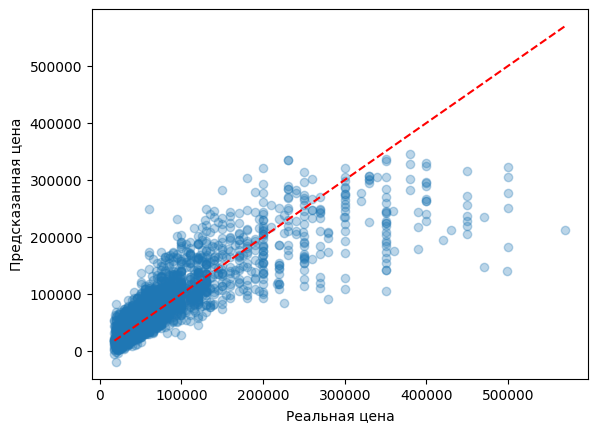

In [5]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Реальная цена")
plt.ylabel("Предсказанная цена")
plt.show()